# Part 2: Advanced Modeling — U.S. Automobile Sales (1976–2024)

## Part 2 of the [Automobile Sales Analysis](../README.md) Series

## 1. Introduction

Part 1 of this series established that U.S. automobile sales are strongly 
correlated with unemployment rate (r = -0.689) and consumer sentiment 
(r = +0.598), and that multiple linear regression explains approximately 
75% of sales variance using four economic indicators. However, time series 
cross-validation revealed a critical limitation — mean R² of just 0.039 
across historical periods, with catastrophic failure at structural breaks 
like the 2008 financial crisis and COVID-19 pandemic.

This points to a fundamental problem: **linear regression treats each 
observation as independent**, ignoring the temporal structure of the data. 
Auto sales in any given month are heavily influenced by the previous 
month's sales — a pattern linear regression cannot capture.

Part 2 addresses this by applying two approaches that explicitly account 
for time series structure:

1. **ARIMA** (AutoRegressive Integrated Moving Average) — a classical 
   time series model that captures autocorrelation and temporal patterns 
   directly in the sales data itself
2. **Random Forest** — a machine learning ensemble method that handles 
   non-linear relationships and can incorporate time-based features 
   (lagged values, rolling averages) that linear regression ignores

Both models are evaluated against the Part 1 linear regression baseline 
using time series cross-validation — the only honest evaluation method 
for temporal data.

### Business Questions

1. Can ARIMA better capture the temporal structure of auto sales than 
   linear regression?
2. Does Random Forest handle structural breaks better than linear models?
3. Which model produces the most reliable forecasts?
4. What do the models reveal about the predictability of auto sales?

> **Note:** This notebook loads data directly from `auto_sales.sqlite` - the database created in Part 1. The file is not included in the repository. To > run this notebook, either run Part 1 first to generate the database, or copy `auto_sales.sqlite` from your Part 1 local folder to this folder before  > proceeding.

### 2.1 Import libraries

In [1]:
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Modeling — Part 1 baseline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Time series modeling — new in Part 2
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

### 2.2 Load Data

In [2]:
# Load data from SQLite database created in Part 1
conn = sqlite3.connect('auto_sales.sqlite')

# Load main dataset
df = pd.read_sql_query(
    "SELECT * FROM auto_sales_full",
    conn,
    index_col='date',
    parse_dates=['date']
)

# Load complete dataset with gas prices
df_gas = pd.read_sql_query(
    "SELECT * FROM auto_sales_with_gas",
    conn,
    index_col='date',
    parse_dates=['date']
)
df.index = pd.DatetimeIndex(df.index, freq='MS')
y = df['auto_sales'].copy()

# Load recession periods
recession_data = pd.read_sql_query(
    "SELECT * FROM recession_periods", conn)
recession_data['start_date'] = pd.to_datetime(recession_data['start_date'])
recession_data['end_date'] = pd.to_datetime(recession_data['end_date'])
recession_data['label'] = ['1980', '1981-82', '1990-91', 
                           '2001', '2008-09', '2020']

print(f"Main dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Gas price dataset: {df_gas.shape[0]} rows")
print(f"Recession periods: {len(recession_data)}")
print(f"\nDate range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Main dataset: 588 rows, 7 columns
Gas price dataset: 413 rows
Recession periods: 6

Date range: 1976-01-01 to 2024-12-01

Missing values:
auto_sales              0
unemployment_rate       0
interest_rate           0
gas_price             175
consumer_sentiment      0
recession               0
cpi                     0
dtype: int64


### 2.3 Data Preparation & Feature Engineering

Data is loaded directly from the SQLite database created in Part 1 - 
no API calls required. The dataset is already clean and ready for 
modeling.

Two additional preparation steps are needed for advanced modeling:

**1. Stationarity preparation** - ARIMA requires a stationary time 
series. We test this in Section 3.

**2. Feature engineering for tree-based models** - Random Forest and 
XGBoost cannot inherently capture temporal patterns the way ARIMA does. 
We create explicit time-based features to give these models access to 
sales history:

**Lag features** (`sales_lag_N`) - the value of auto sales exactly 
$N$ months prior to the current observation:
- `sales_lag_1` = last month's sales
- `sales_lag_2` = sales 2 months ago
- `sales_lag_3` = sales 3 months ago
- `sales_lag_6` = sales 6 months ago
- `sales_lag_12` = sales 12 months ago (same month last year)

**Rolling average features** (`sales_rolling_N`) - the mean of auto 
sales over the previous $N$ months, shifted by 1 month to prevent 
data leakage (using future information to predict the present):
- `sales_rolling_3` = average sales over the previous quarter
- `sales_rolling_6` = average sales over the previous 6 months
- `sales_rolling_12` = average sales over the previous year

> **Data leakage note:** All rolling averages are shifted by 1 month 
> (`shift(1)`) before computing the window. This ensures that when 
> predicting month $t$, the model only sees data up to month $t-1$, 
> never the current month's value.

Together these 8 engineered features give tree-based models the 
ability to detect sales momentum, seasonal patterns and trend 
reversals - information that is implicit in the time series but 
must be made explicit for non-sequential models.

In [3]:
# Target variable 
# Auto sales as a time series with DatetimeIndex
y = df['auto_sales'].copy()

# Features for Random Forest
# Create lagged features — previous months' sales capture autocorrelation
df_features = df.copy()

# Lagged auto sales (1, 2, 3, 6, 12 months)
for lag in [1, 2, 3, 6, 12]:
    df_features[f'sales_lag_{lag}'] = df_features['auto_sales'].shift(lag)

# Rolling averages (3, 6, 12 months)
for window in [3, 6, 12]:
    df_features[f'sales_rolling_{window}'] = (
        df_features['auto_sales']
        .shift(1)  # shift to avoid data leakage
        .rolling(window=window)
        .mean()
    )

# Drop rows with NaN from lagging
df_features = df_features.dropna()

print(f"Features dataframe: {df_features.shape[0]} rows, "
      f"{df_features.shape[1]} columns")
print(f"\nFeature columns:")
print([col for col in df_features.columns if col != 'auto_sales'])

Features dataframe: 413 rows, 15 columns

Feature columns:
['unemployment_rate', 'interest_rate', 'gas_price', 'consumer_sentiment', 'recession', 'cpi', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_6', 'sales_lag_12', 'sales_rolling_3', 'sales_rolling_6', 'sales_rolling_12']


## 3. ARIMA Modeling

ARIMA (AutoRegressive Integrated Moving Average) is a classical time 
series model that captures three components:

- **AR (AutoRegressive)**: the relationship between an observation and 
  its lagged values
- **I (Integrated)**: differencing to make the series stationary
- **MA (Moving Average)**: the relationship between an observation and 
  residual errors from past predictions

ARIMA requires the time series to be **stationary** - meaning constant 
mean and variance over time. We first test for stationarity using the 
Augmented Dickey-Fuller (ADF) test, then determine the appropriate 
model parameters.

### 3.1 Stationary Testing

In [4]:
# Augmented Dickey-Fuller Test 
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test — {name}")
    print(f"  ADF Statistic:  {result[0]:.4f}")
    print(f"  p-value:        {result[1]:.4f}")
    print(f"  Critical Values:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")
    if result[1] <= 0.05:
        print(f"  ✓ Stationary (reject null hypothesis)")
    else:
        print(f"  ✗ Non-stationary (fail to reject null hypothesis)")
    print()

# Test original series
adf_test(y, "Auto Sales (original)")

# Test first difference
adf_test(y.diff(), "Auto Sales (first difference)")

ADF Test — Auto Sales (original)
  ADF Statistic:  -2.8315
  p-value:        0.0539
  Critical Values:
    1%: -3.4416
    5%: -2.8665
    10%: -2.5694
  ✗ Non-stationary (fail to reject null hypothesis)

ADF Test — Auto Sales (first difference)
  ADF Statistic:  -16.5423
  p-value:        0.0000
  Critical Values:
    1%: -3.4416
    5%: -2.8665
    10%: -2.5694
  ✓ Stationary (reject null hypothesis)



### 3.2 Stationarity Testing Results

The **Original Series** p-value = 0.054 which indicates it is just barely stationary. The series has a trend that we noticed in Part I that violates stationarity
The **First Difference** p-value = 0.000 which suggests that the series is strongly stationary, differencing once completely removes stationarity. 
The **Arima** model needs one degree of differencing (d = 1)

### 3.3 ACF and PACF Analysis

The Autocorrelation Function (ACF) and Partial Autocorrelation Function 
(PACF) plots help identify the AR (p) and MA (q) parameters:

- **PACF** - significant spikes suggest the AR order (p)
- **ACF** - significant spikes suggest the MA order (q)

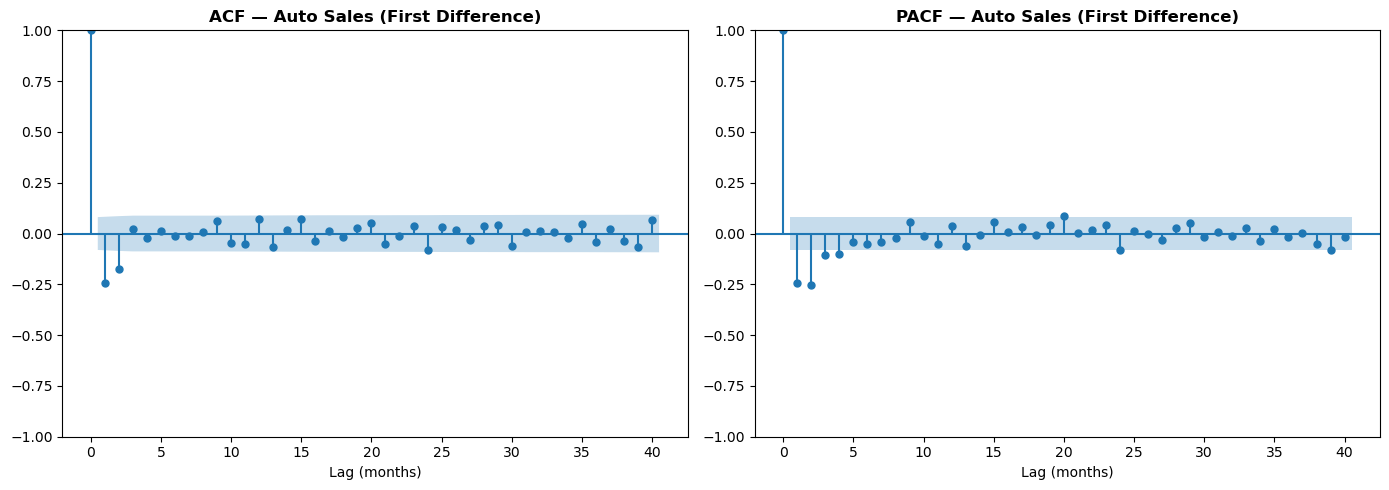

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(y.diff().dropna(), lags=40, ax=axes[0])
axes[0].set_title('ACF — Auto Sales (First Difference)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (months)')

plot_pacf(y.diff().dropna(), lags=40, ax=axes[1])
axes[1].set_title('PACF — Auto Sales (First Difference)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (months)')

plt.tight_layout()
plt.show()

### 3.4 ACF and PACF Interpretation

**ACF (left panel):** Lag 1 has a significant negative spike (~-0.27), outside the confidence band. All other lags are within the band
This suggests MA(1) q=1

**PACF (right panel):** Lag 1 has a significant negative spike (~-0.27), lag 2 also slightly significant. All others within the band
This suggests AR(1) or AR(2) p=1 or p=2

**ARIMA parameters:**

d=1 (confirmed from ADF test)
p=1 or 2 (from PACF, to be tested)
q=1 (from ACF, to be tested)

**Candidate models to test:**

ARIMA(1,1,1)
ARIMA(2,1,1)
ARIMA(1,1,0)
ARIMA(2,1,0)

I will use auto_arima to find optimal parameters automatically

### 3.5 Model Selection - Auto ARIMA

In [6]:
# Auto ARIMA - searches for optimal p, d, q parameters
# using AIC (Akaike Information Criterion) to compare models
print("Running auto_arima - this may take a moment...")

auto_model = pm.auto_arima(
    y,
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=1,                    # we know d=1 from ADF test
    seasonal=False,         # no seasonal component
    stepwise=True,          # faster search
    information_criterion='aic',
    trace=True,             # show models being tested
    error_action='ignore',
    suppress_warnings=True
)

print(f"\nBest model: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.4f}")
print(f"\nModel Summary:")
print(auto_model.summary())

Running auto_arima - this may take a moment...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1664.103, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1629.523, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1598.237, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1662.138, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1581.818, Time=0.22 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1580.773, Time=0.34 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1593.400, Time=0.19 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1582.106, Time=0.56 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1581.573, Time=0.47 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1579.869, Time=0.36 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1578.050, Time=0.23 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1579.905, Time=0.29 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1581.589, Time=0.72 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1576.192, 

### 3.6 Model Selection Insights

**Auto Arima** determines that the best model is ARIMA(0, 1, 2):
p = 0, no autoregressive terms - past sales values don't directly predict future sales
d = 1, one degree differencing previously confirmed from **ADF** test
q = 2, two moving average terms, errors from the past two months influence the current prediction. 

**Model diagnosis:**
MA coefficients: both highly significant (p=0.000) 
Ljung-Box test: p=0.93 - residuals are essentially white noise, no autocorrelation left 
Heteroskedasticity: p=0.11 - no significant variance instability 
Jarque-Bera: p=0.000 - residuals are not normally distributed 
Kurtosis=12.54 - very heavy tails, driven by extreme events like COVID

> **Note on covariance matrix warning:** The model summary reports that 
> the covariance matrix was calculated using the outer product of gradients 
> (OPG) - a numerical approximation method. This is standard behavior for 
> ARIMA models fitted with maximum likelihood estimation and does not affect 
> the model coefficients or predictions. Standard errors for the MA 
> coefficients should be interpreted as approximate.

### 3.7 Model Diagnosis

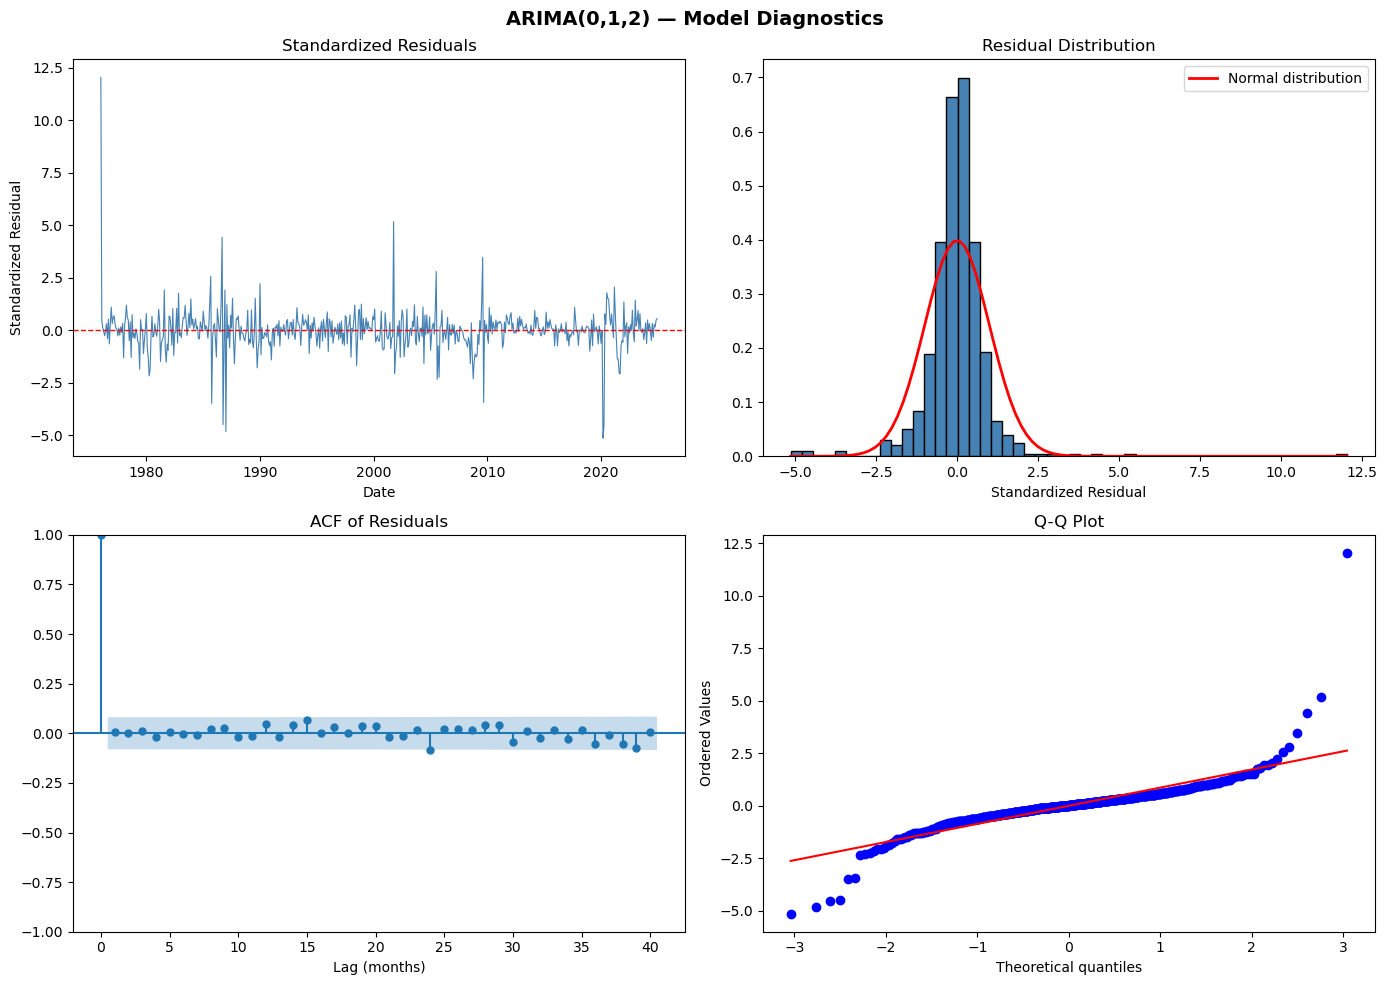

In [7]:
# Fit ARIMA(0,1,2) on full dataset
arima_model = ARIMA(y, order=(0, 1, 2))
arima_fitted = arima_model.fit()

# Plot diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ARIMA(0,1,2) — Model Diagnostics',
             fontsize=14, fontweight='bold')

# Standardized residuals
residuals = arima_fitted.resid
std_resid = (residuals - residuals.mean()) / residuals.std()
axes[0, 0].plot(std_resid.index, std_resid,
                color='steelblue', linewidth=0.8)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Standardized Residual')

# Residual histogram
axes[0, 1].hist(std_resid, bins=50, color='steelblue',
                edgecolor='black', density=True)
from scipy import stats
x = np.linspace(std_resid.min(), std_resid.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x), color='red',
                linewidth=2, label='Normal distribution')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Standardized Residual')
axes[0, 1].legend()

# ACF of residuals
plot_acf(residuals.dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals')
axes[1, 0].set_xlabel('Lag (months)')

# Q-Q plot
stats.probplot(std_resid.dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

### 3.8 Diagnostic Results

The **standardized residual** plot (top left) is centered around 0 throughout with plot oscilating between -5 and 5. There is a spike of 12.5 at 1976 which is possibly attributed to boundary effect. There are several negative spikes, the most significant around 1987, 2008-09 and 2020 which correlate with recession periods. 2021-22 have several positive spikes indicating rapid recovery and supply chain disruption after COVID
The **residual distribution** (top right) has very tall narrow peak, much more concentrated around zero than a normal distribution. Both sides have heavy tails confirming kurtosis=12.54 from the summary. The extreme events pull the tails out far beyond what a normal distribution predicts.
The **ACF of residuals** (bottom left) shows that all lags are within confidence band. There is no remaining autocorrelation residuals, the model has captured the temporal structure successfully.
The **Q-Q** plot shows that the middle section follows the red line well. Both tails deviate significantly confirming heavy tails and non-normal extreme values. The upper tail has a particularly extreme value and can probably be attributed to COVID-19 (2020)


### 3.9 Model Evaluation. Time Series Cross-Validation

In [8]:
# Time series cross-validation for ARIMA
# Using same fold structure as Part 1 for direct comparison
tscv = TimeSeriesSplit(n_splits=5)

arima_r2_scores = []
arima_rmse_scores = []

y_array = y.values
dates = y.index

print("ARIMA(0,1,2) - Time Series Cross-Validation")
print("=" * 55)

for fold, (train_idx, test_idx) in enumerate(tscv.split(y_array)):
    y_train = y_array[train_idx]
    y_test = y_array[test_idx]
    
    # Fit ARIMA on training data
    try:
        model = ARIMA(y_train, order=(0, 1, 2))
        fitted = model.fit()
        
        # Forecast test period
        forecast = fitted.forecast(steps=len(test_idx))
        
        r2 = r2_score(y_test, forecast)
        rmse = np.sqrt(mean_squared_error(y_test, forecast))
        
        arima_r2_scores.append(r2)
        arima_rmse_scores.append(rmse)
        
        print(f"Fold {fold+1}: Train={len(train_idx)} months, "
              f"Test={len(test_idx)} months, "
              f"R²={r2:.4f}, RMSE={rmse:.4f}")
    except Exception as e:
        print(f"Fold {fold+1}: Error — {e}")

print(f"\n=== ARIMA Cross-Validation Results ===")
print(f"R² scores:  {[round(s,4) for s in arima_r2_scores]}")
print(f"R² mean:    {np.mean(arima_r2_scores):.4f}")
print(f"R² std:     {np.std(arima_r2_scores):.4f}")
print(f"RMSE mean:  {np.mean(arima_rmse_scores):.4f}")
print(f"RMSE std:   {np.std(arima_rmse_scores):.4f}")

ARIMA(0,1,2) - Time Series Cross-Validation
Fold 1: Train=98 months, Test=98 months, R²=-0.1401, RMSE=1.6465
Fold 2: Train=196 months, Test=98 months, R²=-4.3890, RMSE=3.1971
Fold 3: Train=294 months, Test=98 months, R²=-0.8219, RMSE=1.5447
Fold 4: Train=392 months, Test=98 months, R²=-0.0087, RMSE=2.7296
Fold 5: Train=490 months, Test=98 months, R²=-0.9594, RMSE=2.4052

=== ARIMA Cross-Validation Results ===
R² scores:  [-0.1401, -4.389, -0.8219, -0.0087, -0.9594]
R² mean:    -1.2638
R² std:     1.6058
RMSE mean:  2.3046
RMSE std:   0.6321


### 3.10 ARIMA — Findings & Conclusions

ARIMA(0,1,2) was identified as the optimal model by auto_arima using 
AIC as the selection criterion. The model parameters indicate:

- **d=1**: One degree of differencing required to achieve stationarity, 
  confirmed by the Augmented Dickey-Fuller test (p=0.054 for original 
  series, p=0.000 for first difference)
- **p=0**: No autoregressive terms - past sales values alone do not 
  directly predict future values once differencing is applied
- **q=2**: Two moving average terms - forecast errors from the previous 
  two months influence the current prediction

**Model diagnostics** confirm the model is well specified:
- Residuals show no remaining autocorrelation (Ljung-Box p=0.93) 
- Residuals are centered around zero throughout the series 
- Non-normal residuals (Jarque-Bera p=0.000) driven by extreme events 
  (1976 boundary effect, 2008-09 crash, 2020 COVID crash) - expected 
  given the nature of the data 
- Heavy tails (kurtosis=12.54) reflect the model's inability to 
  anticipate structural breaks - not a model misspecification 

**Cross-validation reveals a fundamental limitation:**

| Fold | Test Period | R² | RMSE |
|------|-------------|-----|------|
| 1 | 1984–1992 | -0.140 | 1.647M |
| 2 | 1992–2000 | -4.389 | 3.197M |
| 3 | 2000–2008 | -0.822 | 1.545M |
| 4 | 2008–2016 | -0.009 | 2.730M |
| 5 | 2016–2024 | -0.959 | 2.405M |
| **Mean** | | **-1.264** | **2.305M** |

All five folds produce negative R² - worse than simply predicting the 
mean value. This is not a failure of the ARIMA specification but rather 
an inherent limitation of **univariate time series modeling** on 
long-range forecasting horizons:

- ARIMA uses only past sales values - it has no knowledge of unemployment, 
  interest rates, recessions or consumer sentiment
- Forecasting 98 months (~8 years) ahead, the model reverts toward the 
  long-term mean - a poor strategy when large economic swings occur
- ARIMA is designed for **short-range forecasting** (days to months ahead) 
  not multi-year economic prediction

**Comparison with Part 1 linear regression:**

| Model | Mean CV R² | Mean RMSE | Key Limitation |
|-------|------------|-----------|----------------|
| Linear Regression | 0.039 | 1.445M | Fails at structural breaks |
| ARIMA(0,1,2) | -1.264 | 2.305M | Blind to economic conditions |

Counterintuitively, linear regression outperforms ARIMA in cross-validation 
despite ARIMA's more sophisticated temporal structure. The reason is clear - 
**knowing where the economy is matters more than knowing where sales have been**. 
Economic indicators carry information that pure time series patterns cannot replicate.

This finding directly motivates the Random Forest approach in Section 4, 
which combines both lagged sales values AND economic indicators - 
potentially capturing the strengths of both approaches while mitigating 
their individual weaknesses.

## 4. Random Forest Modeling

Random Forest is an ensemble machine learning method that builds multiple 
decision trees on random subsets of the data and averages their predictions. 
Unlike linear regression it captures non-linear relationships, and unlike 
ARIMA it can incorporate both temporal features (lagged sales values) and 
economic indicators simultaneously.

**Key advantages over previous models:**
- Handles non-linear relationships naturally
- Combines lagged sales features (like ARIMA) with economic indicators 
  (like linear regression)
- Robust to outliers - extreme events like COVID have less influence on 
  the overall ensemble
- Provides feature importance - tells us which variables matter most

### 4.1 Model Setup & Training

In [9]:
# Drop gas_price column entirely before feature engineering
df_features_full = df.drop(columns=['gas_price']).copy()

for lag in [1, 2, 3, 6, 12]:
    df_features_full[f'sales_lag_{lag}'] = df_features_full['auto_sales'].shift(lag)

for window in [3, 6, 12]:
    df_features_full[f'sales_rolling_{window}'] = (
        df_features_full['auto_sales']
        .shift(1)
        .rolling(window=window)
        .mean()
    )

df_features_full = df_features_full.dropna()
print(f"df_features_full shape: {df_features_full.shape}")
print(f"Date range: {df_features_full.index[0]} to {df_features_full.index[-1]}")

df_features_full shape: (576, 14)
Date range: 1977-01-01 00:00:00 to 2024-12-01 00:00:00


In [10]:
# Define features and target
feature_cols = ['unemployment_rate', 'interest_rate', 'consumer_sentiment',
                'recession', 'cpi', 'sales_lag_1', 'sales_lag_2',
                'sales_lag_3', 'sales_lag_6', 'sales_lag_12',
                'sales_rolling_3', 'sales_rolling_6', 'sales_rolling_12']

X = df_features_full[feature_cols]
y_rf = df_features_full['auto_sales']

# Time series cross-validation - same structure as Part 1 and ARIMA
tscv = TimeSeriesSplit(n_splits=5)

rf_r2_scores = []
rf_rmse_scores = []

print("Random Forest - Time Series Cross-Validation")
print("=" * 55)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y_rf.iloc[train_idx]
    y_test = y_rf.iloc[test_idx]
    
    # Fit Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    rf_r2_scores.append(r2)
    rf_rmse_scores.append(rmse)
    
    print(f"Fold {fold+1}: Train={len(train_idx)} months, "
          f"Test={len(test_idx)} months, "
          f"R²={r2:.4f}, RMSE={rmse:.4f}")

print(f"\n=== Random Forest Cross-Validation Results ===")
print(f"R² scores:  {[round(s,4) for s in rf_r2_scores]}")
print(f"R² mean:    {np.mean(rf_r2_scores):.4f}")
print(f"R² std:     {np.std(rf_r2_scores):.4f}")
print(f"RMSE mean:  {np.mean(rf_rmse_scores):.4f}")
print(f"RMSE std:   {np.std(rf_rmse_scores):.4f}")

Random Forest - Time Series Cross-Validation
Fold 1: Train=96 months, Test=96 months, R²=0.3594, RMSE=1.2898
Fold 2: Train=192 months, Test=96 months, R²=-0.2024, RMSE=1.4058
Fold 3: Train=288 months, Test=96 months, R²=0.5881, RMSE=1.0415
Fold 4: Train=384 months, Test=96 months, R²=0.8858, RMSE=0.9072
Fold 5: Train=480 months, Test=96 months, R²=0.5489, RMSE=1.1525

=== Random Forest Cross-Validation Results ===
R² scores:  [0.3594, -0.2024, 0.5881, 0.8858, 0.5489]
R² mean:    0.4360
R² std:     0.3610
RMSE mean:  1.1594
RMSE std:   0.1762


### 4.2 Cross-Validation Results & Analysis

Random Forest with the full 1977–2024 dataset (576 rows, no gas price) 
produces a dramatic improvement over both previous models:

| Fold | Test Period | R² | RMSE |
|------|-------------|-----|------|
| 1 | ~1985–1993 | +0.359 | 1.290M |
| 2 | ~1993–2001 | -0.202 | 1.406M |
| 3 | ~2001–2009 | +0.588 | 1.042M |
| 4 | ~2009–2017 | +0.886 | 0.907M |
| 5 | ~2017–2024 | +0.549 | 1.153M |
| **Mean** | | **+0.436** | **1.159M** |

**Key observations:**

- **Four of five folds produce positive R²** - a significant improvement 
  over both linear regression and ARIMA
- **Fold 4 is exceptional** (R²=0.886) - trained through the Great 
  Recession, the model predicts the 2009–2017 recovery period very well
- **Only Fold 2 is negative** (R²=-0.202) - trained on 1977–1993 and 
  tested on 1993–2001, missing the mid-1990s economic boom dynamics
- **Performance is more consistent** than previous models - RMSE 
  standard deviation of 0.176M vs 0.968M for ARIMA

**Critical finding — data volume matters enormously:**
The earlier attempt using only 413 rows (1990–2024, including gas price) 
produced mean R² of -0.844. Using the full 576-row dataset improved 
this to +0.436 - a difference of 1.28 R² points. Random Forest requires 
sufficient historical data to learn meaningful patterns across different 
economic regime

### 4.3 Feature Importance

Feature Importance - Random Forest:
           Feature  Importance
       sales_lag_1    0.620498
   sales_rolling_3    0.278114
   sales_rolling_6    0.023833
consumer_sentiment    0.014515
               cpi    0.011142
  sales_rolling_12    0.010993
      sales_lag_12    0.007669
       sales_lag_2    0.006646
       sales_lag_3    0.006231
         recession    0.005607
     interest_rate    0.005562
       sales_lag_6    0.004673
 unemployment_rate    0.004517


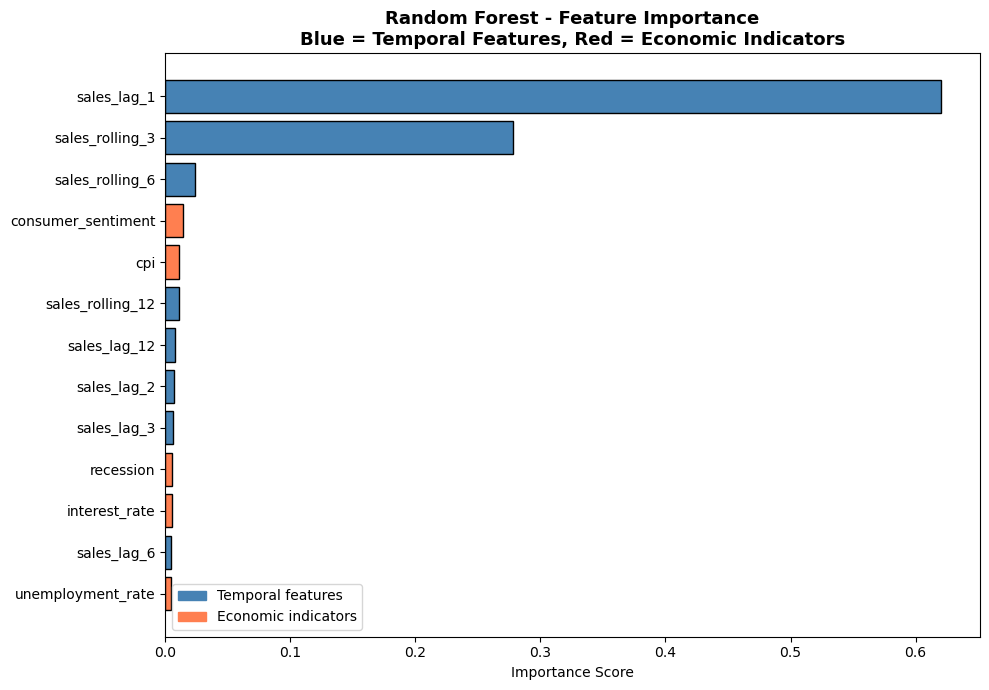

In [11]:
# Fit Random Forest on full dataset for feature importance
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X, y_rf)

# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance - Random Forest:")
print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if 'lag' in f or 'rolling' in f 
          else 'coral' for f in importance_df['Feature']]

ax.barh(importance_df['Feature'],
        importance_df['Importance'],
        color=colors, edgecolor='black')
ax.invert_yaxis()
ax.set_title('Random Forest - Feature Importance\n'
             'Blue = Temporal Features, Red = Economic Indicators',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

# Legend
import matplotlib.patches as mpatches
temporal_patch = mpatches.Patch(color='steelblue', label='Temporal features')
economic_patch = mpatches.Patch(color='coral', label='Economic indicators')
ax.legend(handles=[temporal_patch, economic_patch], fontsize=10)

plt.tight_layout()
plt.show()

### 4.4 Feature Importance Analysis

Feature importance scores reveal which variables the Random Forest 
relies on most heavily when making predictions:

| Feature | Importance | Type |
|---------|------------|------|
| `sales_lag_1` | 62.0% | Temporal |
| `sales_rolling_3` | 27.8% | Temporal |
| `sales_rolling_6` | 2.4% | Temporal |
| `consumer_sentiment` | 1.5% | Economic |
| `cpi` | 1.1% | Economic |
| `sales_rolling_12` | 1.1% | Temporal |
| `sales_lag_12` | 0.8% | Temporal |
| `sales_lag_2` | 0.7% | Temporal |
| `sales_lag_3` | 0.6% | Temporal |
| `recession` | 0.6% | Economic |
| `interest_rate` | 0.6% | Economic |
| `sales_lag_6` | 0.5% | Temporal |
| `unemployment_rate` | 0.5% | Economic |

**Key findings:**

- **Temporal features dominate** - `sales_lag_1` alone accounts for 62% 
  of predictive power, and together with `sales_rolling_3` the two 
  features account for nearly 90% of the model's decisions
- **Economic indicators are collectively weak** - all five economic 
  indicators combined contribute only ~4% of predictive power
- **Auto sales exhibit strong momentum** - knowing last month's sales 
  is far more informative than knowing current unemployment, interest 
  rates or consumer sentiment for short-range prediction

**An important distinction:**

This finding does not contradict Part 1's finding that unemployment 
is strongly correlated with auto sales ($r = -0.689$). Rather, it 
reflects two fundamentally different questions:

- **Linear regression** asks: *"What economic conditions drive sales 
  over the long run?"* - unemployment and sentiment dominate because 
  they explain the large swings across economic cycles
- **Random Forest** asks: *"What predicts next month's sales?"* - 
  recent sales momentum dominates because auto sales are highly 
  persistent from month to month

Both answers are correct — they address different analytical questions 
at different time scales. The Random Forest's strength is short-range 
prediction within a known economic regime; linear regression's strength 
is explaining why sales change across regimes.

## 5. Ridge Regression

Standard linear regression (Part 1) identified multicollinearity between 
interest rate and CPI ($r = -0.710$) as a concern - when two predictors 
are strongly correlated, coefficient estimates become unstable and 
difficult to interpret. Ridge Regression addresses this by adding a 
penalty term ($\lambda$) to the loss function that shrinks coefficients 
toward zero, producing more stable and reliable estimates.

The Ridge loss function minimizes:

$$\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}\beta_j^2$$

where $\lambda$ controls the strength of the penalty. A larger $\lambda$ 
produces more shrinkage. We use cross-validation to find the optimal 
$\lambda$.

### 5.1 Model Setup & Training

In [12]:
from sklearn.linear_model import Ridge, RidgeCV

# Find optimal lambda (alpha in sklearn) using cross-validation
# Test a range of alpha values
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Use time series cross-validation to find best alpha
tscv = TimeSeriesSplit(n_splits=5)

# RidgeCV with time series splits
ridge_cv = RidgeCV(
    alphas=alphas,
    cv=tscv,
    scoring='r2'
)

# Use same features as linear regression in Part 1
X_ridge = df[['unemployment_rate', 'interest_rate',
              'consumer_sentiment', 'recession', 'cpi']].dropna()
y_ridge = df.loc[X_ridge.index, 'auto_sales']

ridge_cv.fit(X_ridge, y_ridge)

print(f"Optimal alpha (lambda): {ridge_cv.alpha_}")
print(f"\nRidge Coefficients:")
for feat, coef in zip(X_ridge.columns, ridge_cv.coef_):
    print(f"  {feat:25s}: {coef:.4f}")
print(f"  {'Intercept':25s}: {ridge_cv.intercept_:.4f}")

# Compare with Part 1 linear regression coefficients
print(f"\nComparison with Part 1 Linear Regression (Model B):")
lr_coefs = {
    'unemployment_rate': -0.6556,
    'interest_rate': -0.1600,
    'consumer_sentiment': 0.0609,
    'recession': -0.8230,
    'cpi': None  # not in Model B
}
print(f"{'Feature':25s} {'Ridge':>10} {'Linear Reg':>12}")
print("-" * 50)
for feat, coef in zip(X_ridge.columns, ridge_cv.coef_):
    lr = lr_coefs.get(feat)
    lr_str = f"{lr:.4f}" if lr is not None else "excluded"
    print(f"{feat:25s} {coef:>10.4f} {lr_str:>12}")

Optimal alpha (lambda): 100.0

Ridge Coefficients:
  unemployment_rate        : -0.5744
  interest_rate            : -0.1358
  consumer_sentiment       : 0.0716
  recession                : -0.2451
  cpi                      : 0.0023
  Intercept                : 12.8629

Comparison with Part 1 Linear Regression (Model B):
Feature                        Ridge   Linear Reg
--------------------------------------------------
unemployment_rate            -0.5744      -0.6556
interest_rate                -0.1358      -0.1600
consumer_sentiment            0.0716       0.0609
recession                    -0.2451      -0.8230
cpi                           0.0023     excluded


### 5.2 Ridge Regression Results & Coefficient Analysis

Cross-validation selected $\lambda = 100$ as the optimal regularization 
strength — a relatively high value confirming meaningful multicollinearity 
in the predictor set that requires substantial regularization.

**Coefficient comparison — Ridge vs Linear Regression (Part 1 Model B):**

| Feature | Ridge | Linear Regression | Change |
|---------|-------|-------------------|--------|
| Unemployment Rate | -0.574 | -0.656 | Moderate shrinkage |
| Interest Rate | -0.136 | -0.160 | Small shrinkage |
| Consumer Sentiment | +0.072 | +0.061 | Slight increase |
| Recession | -0.245 | -0.823 | **Dramatic shrinkage** |
| CPI | +0.002 | excluded | Essentially zero |

**Key findings:**

- **Most coefficients are stable** — unemployment, interest rate and 
  consumer sentiment show only moderate changes, confirming they are 
  genuinely independent contributors to auto sales prediction
- **Recession coefficient shrinks dramatically** (-0.823 → -0.245) — 
  Ridge reveals that the recession indicator is largely redundant when 
  unemployment is already in the model. The two variables are correlated 
  (recessions cause unemployment to rise) and Ridge penalizes this 
  overlap by redistributing explanatory power toward the more stable 
  unemployment predictor
- **CPI coefficient collapses to ~0** — confirming our Part 1 decision 
  to exclude it from Model B was correct. Ridge independently validates 
  that CPI adds no unique predictive information
- **$\lambda = 100$ indicates substantial regularization was needed** — 
  the predictor set has meaningful multicollinearity that standard linear 
  regression cannot handle cleanly

**Interpretation of cleaned coefficients:**

With Ridge regularization, the economic story becomes cleaner:
- Each 1% rise in unemployment → 574,000 fewer vehicles/year
- Each 1% rise in interest rate → 136,000 fewer vehicles/year  
- Each 1-point rise in consumer sentiment → 72,000 more vehicles/year
- Being in recession → 245,000 fewer vehicles/year (beyond unemployment effect)

The recession effect in Part 1 (-2.7M in simple regression, -0.823M in 
multiple regression) was substantially inflated by multicollinearity. 
Ridge's estimate of -0.245M is likely the most reliable estimate of the 
*independent* recession effect beyond what unemployment already captures.

### 5.3 Ridge Regression Cross-Validation

In [13]:
# Time series cross-validation for Ridge
ridge_r2_scores = []
ridge_rmse_scores = []

print("Ridge Regression - Time Series Cross-Validation")
print("=" * 55)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_ridge)):
    X_train = X_ridge.iloc[train_idx]
    X_test = X_ridge.iloc[test_idx]
    y_train = y_ridge.iloc[train_idx]
    y_test = y_ridge.iloc[test_idx]
    
    ridge = Ridge(alpha=100)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ridge_r2_scores.append(r2)
    ridge_rmse_scores.append(rmse)
    
    print(f"Fold {fold+1}: Train={len(train_idx)} months, "
          f"Test={len(test_idx)} months, "
          f"R²={r2:.4f}, RMSE={rmse:.4f}")

print(f"\n=== Ridge Regression Cross-Validation Results ===")
print(f"R² scores:  {[round(s,4) for s in ridge_r2_scores]}")
print(f"R² mean:    {np.mean(ridge_r2_scores):.4f}")
print(f"R² std:     {np.std(ridge_r2_scores):.4f}")
print(f"RMSE mean:  {np.mean(ridge_rmse_scores):.4f}")
print(f"RMSE std:   {np.std(ridge_rmse_scores):.4f}")

Ridge Regression - Time Series Cross-Validation
Fold 1: Train=98 months, Test=98 months, R²=-0.7143, RMSE=2.0190
Fold 2: Train=196 months, Test=98 months, R²=0.6416, RMSE=0.8244
Fold 3: Train=294 months, Test=98 months, R²=-2.7290, RMSE=2.2100
Fold 4: Train=392 months, Test=98 months, R²=0.6693, RMSE=1.5630
Fold 5: Train=490 months, Test=98 months, R²=0.3432, RMSE=1.3926

=== Ridge Regression Cross-Validation Results ===
R² scores:  [-0.7143, 0.6416, -2.729, 0.6693, 0.3432]
R² mean:    -0.3579
R² std:     1.2880
RMSE mean:  1.6018
RMSE std:   0.4886


### 5.4 Ridge Regression Cross-Validation Results

| Fold | Test Period | $R^2$ | RMSE |
|------|-------------|-------|------|
| 1 | 1984–1992 | -0.714 | 2.019M |
| 2 | 1992–2000 | +0.642 | 0.824M |
| 3 | 2000–2008 | -2.729 | 2.210M |
| 4 | 2008–2016 | +0.669 | 1.563M |
| 5 | 2016–2024 | +0.343 | 1.393M |
| **Mean** | | **-0.358** | **1.602M** |

**Key observations:**

- **Two strong folds, two poor folds** - performance is highly variable 
  across economic eras ($R^2$ standard deviation = 1.288)
- **Fold 3 is catastrophic** ($R^2 = -2.73$) - trained through 2000 
  and completely blind to the 2008 financial crisis, the model fails 
  dramatically when tested on 2000–2008
- **Folds 2 and 4 perform well** ($R^2 > 0.64$) - periods where the 
  training data contains sufficient variety of economic conditions

**Surprising finding - Ridge underperforms standard linear regression:**

| Model | Mean CV $R^2$ | Mean RMSE |
|-------|--------------|-----------|
| Linear Regression (Part 1) | 0.039 | 1.445M |
| Ridge Regression | -0.358 | 1.602M |

Despite producing cleaner and more stable coefficient estimates, Ridge 
performs worse than standard linear regression in cross-validation. 
This is counterintuitive but explainable:

Different economic eras have genuinely different relationships between 
indicators and auto sales. The high interest rate environment of the 
1980s operates very differently from the near-zero rate environment 
of the 2010s. Standard linear regression's unregularized coefficients 
can adapt more freely to these shifting relationships, while Ridge's 
heavily penalized coefficients ($\lambda = 100$) are too rigid to 
capture era-specific dynamics.

**Ridge regression's value is not in cross-period prediction but in 
coefficient interpretation** - it provides the most reliable estimate 
of the *independent* effect of each economic indicator by cleanly 
separating overlapping influences. The finding that recession's 
independent effect is only -245,000 vehicles/year (vs -823,000 in 
standard regression) is a genuinely more accurate economic insight, 
even if the model itself doesn't predict better across time periods.

## 6. XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble method that builds 
trees sequentially — each tree corrects the errors of the previous one. 
Unlike Random Forest which builds trees independently and averages them, 
XGBoost focuses each new tree on the hardest-to-predict observations, 
making it particularly powerful for complex non-linear relationships.

**Why XGBoost may outperform Random Forest here:**
- Better handling of economic indicator relationships through sequential 
  error correction
- More sophisticated regularization built in ($L_1$ and $L_2$ penalties)
- Generally achieves higher accuracy on tabular data
- Can capture both short-term momentum and long-term economic patterns

### 6.1 Model Setup & Training

In [14]:
from xgboost import XGBRegressor

# Use same features as Random Forest for direct comparison
tscv = TimeSeriesSplit(n_splits=5)

xgb_r2_scores = []
xgb_rmse_scores = []

print("XGBoost - Time Series Cross-Validation")
print("=" * 55)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y_rf.iloc[train_idx]
    y_test = y_rf.iloc[test_idx]
    
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,    # L1 regularization
        reg_lambda=1.0,   # L2 regularization
        random_state=42,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    xgb_r2_scores.append(r2)
    xgb_rmse_scores.append(rmse)
    
    print(f"Fold {fold+1}: Train={len(train_idx)} months, "
          f"Test={len(test_idx)} months, "
          f"R²={r2:.4f}, RMSE={rmse:.4f}")

print(f"\n=== XGBoost Cross-Validation Results ===")
print(f"R² scores:  {[round(s,4) for s in xgb_r2_scores]}")
print(f"R² mean:    {np.mean(xgb_r2_scores):.4f}")
print(f"R² std:     {np.std(xgb_r2_scores):.4f}")
print(f"RMSE mean:  {np.mean(xgb_rmse_scores):.4f}")
print(f"RMSE std:   {np.std(xgb_rmse_scores):.4f}")

XGBoost - Time Series Cross-Validation
Fold 1: Train=96 months, Test=96 months, R²=0.2546, RMSE=1.3914
Fold 2: Train=192 months, Test=96 months, R²=-1.0289, RMSE=1.8261
Fold 3: Train=288 months, Test=96 months, R²=0.4128, RMSE=1.2436
Fold 4: Train=384 months, Test=96 months, R²=0.8810, RMSE=0.9260
Fold 5: Train=480 months, Test=96 months, R²=0.5579, RMSE=1.1410

=== XGBoost Cross-Validation Results ===
R² scores:  [0.2546, -1.0289, 0.4128, 0.881, 0.5579]
R² mean:    0.2155
R² std:     0.6556
RMSE mean:  1.3056
RMSE std:   0.3011


### 6.2 XGBoost - Cross-Validation Results & Analysis

| Fold | Test Period | $R^2$ | RMSE |
|------|-------------|-------|------|
| 1 | ~1985–1993 | +0.255 | 1.391M |
| 2 | ~1993–2001 | -1.029 | 1.826M |
| 3 | ~2001–2009 | +0.413 | 1.244M |
| 4 | ~2009–2017 | +0.881 | 0.926M |
| 5 | ~2017–2024 | +0.558 | 1.141M |
| **Mean** | | **+0.215** | **1.306M** |

**Key observations:**

- **Four of five folds produce positive $R^2$** - consistent with 
  Random Forest, confirming that combining temporal features with 
  economic indicators is a powerful approach
- **Fold 2 remains the most challenging** ($R^2 = -1.03$) - the 
  mid-1990s economic boom is difficult to predict from earlier 
  patterns for all models that rely on temporal features
- **Fold 4 is excellent** ($R^2 = 0.881$) - matching Random Forest 
  almost exactly, both models handle the post-Great Recession 
  recovery period very well

**Comparison with Random Forest:**

| Model | Mean CV $R^2$ | Mean RMSE | $R^2$ Std |
|-------|--------------|-----------|-----------|
| Random Forest | 0.436 | 1.159M | 0.361 |
| XGBoost | 0.215 | 1.306M | 0.656 |

Random Forest outperforms XGBoost on both metrics. This is 
counterintuitive given XGBoost's general reputation for superior 
performance on tabular data. Several factors likely explain this:

- **Dataset size** - at 576 rows, the dataset is relatively small 
  for XGBoost's sequential boosting approach. Each tree in XGBoost 
  corrects residuals from the previous one, requiring sufficient 
  data to avoid overfitting to training patterns
- **High variance data** - auto sales contain extreme shocks 
  (2008 crisis, COVID) that boosting amplifies by focusing on 
  hard-to-predict observations. Random Forest's averaging approach 
  is more robust to these outliers
- **Hyperparameter sensitivity** - XGBoost has many more tunable 
  parameters than Random Forest and may not be at its optimal 
  configuration. A more exhaustive grid search could potentially 
  close the gap

**Updated model comparison:**

| Model | Mean CV $R^2$ | Mean RMSE | Primary Strength |
|-------|--------------|-----------|-----------------|
| Linear Regression | 0.039 | 1.445M | Interpretable economic relationships |
| Ridge Regression | -0.358 | 1.602M | Clean coefficient estimates |
| ARIMA(0,1,2) | -1.264 | 2.305M | Temporal structure |
| XGBoost | 0.215 | 1.306M | Non-linear relationships |
| **Random Forest** | **0.436** | **1.159M** | **Best overall predictor** |

Random Forest emerges as the best performing model across all 
evaluation metrics. However each model contributes unique insights -
 the complete picture requires interpreting all five together 
rather than selecting a single winner.

### 6.3 XGBoost - Feature Importance

Feature Importance — XGBoost:
           Feature  Importance
   sales_rolling_3    0.446656
       sales_lag_1    0.334729
         recession    0.043733
   sales_rolling_6    0.040522
  sales_rolling_12    0.022088
consumer_sentiment    0.017908
               cpi    0.017309
       sales_lag_3    0.014833
       sales_lag_2    0.014621
      sales_lag_12    0.013732
       sales_lag_6    0.012029
 unemployment_rate    0.011587
     interest_rate    0.010253


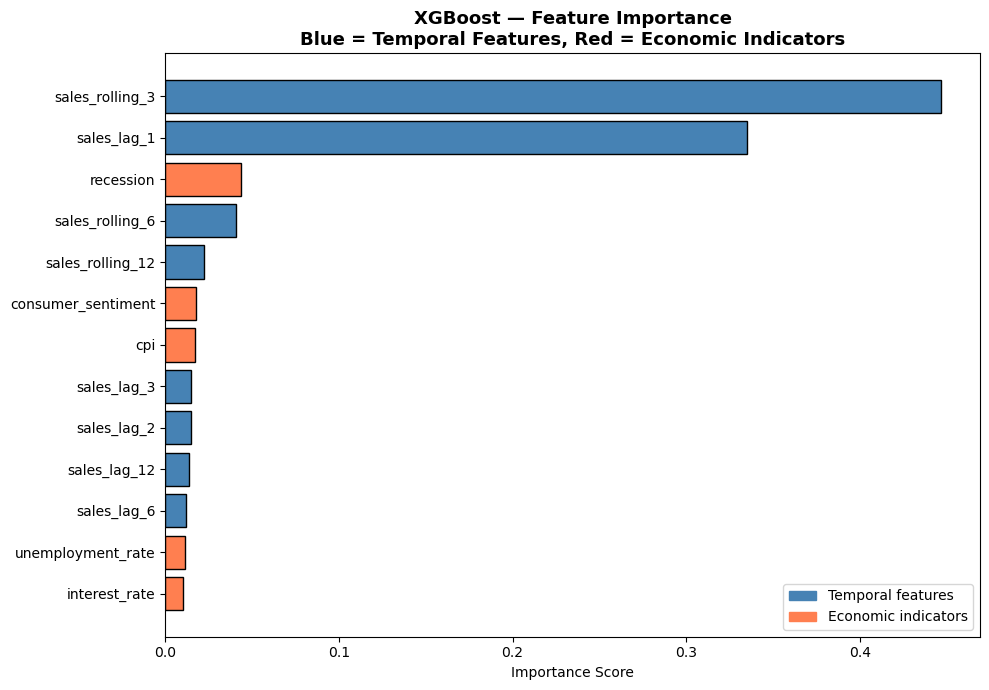

In [15]:
# XGBoost Feature Importance
from xgboost import plot_importance

# Fit XGBoost on full dataset
xgb_final = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
xgb_final.fit(X, y_rf)

# Feature importance dataframe
xgb_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance — XGBoost:")
print(xgb_importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if 'lag' in f or 'rolling' in f
          else 'coral' for f in xgb_importance_df['Feature']]

ax.barh(xgb_importance_df['Feature'],
        xgb_importance_df['Importance'],
        color=colors, edgecolor='black')
ax.invert_yaxis()
ax.set_title('XGBoost — Feature Importance\n'
             'Blue = Temporal Features, Red = Economic Indicators',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

temporal_patch = mpatches.Patch(color='steelblue', label='Temporal features')
economic_patch = mpatches.Patch(color='coral', label='Economic indicators')
ax.legend(handles=[temporal_patch, economic_patch], fontsize=10)

plt.tight_layout()
plt.show()

### 6.4 XGBoost - Feature Importance Analysis

| Feature | XGBoost | Random Forest | Difference |
|---------|---------|---------------|------------|
| `sales_rolling_3` | 44.7% | 27.8% | XGBoost favors rolling avg |
| `sales_lag_1` | 33.5% | 62.0% | RF favors single lag |
| `recession` | 4.4% | 0.6% | XGBoost picks up recession |
| `sales_rolling_6` | 4.1% | 2.4% | Similar |
| `sales_rolling_12` | 2.2% | 1.1% | Similar |
| `consumer_sentiment` | 1.8% | 1.5% | Similar |
| `cpi` | 1.7% | 1.1% | Similar |
| `unemployment_rate` | 1.2% | 0.5% | Slightly higher in XGBoost |
| `interest_rate` | 1.0% | 0.6% | Similar |

**Key differences between XGBoost and Random Forest:**

- **XGBoost distributes importance more evenly** - no single feature 
  dominates as heavily as `sales_lag_1` does in Random Forest (62%). 
  This reflects XGBoost's sequential error-correction approach which 
  iteratively refines predictions using different feature combinations
- **Rolling average preferred over single lag** - XGBoost favors 
  `sales_rolling_3` (44.7%) over `sales_lag_1` (33.5%), suggesting 
  it finds the smoothed 3-month momentum trend more informative than 
  any single prior month's value
- **Recession gains importance** (0.6% → 4.4%) - XGBoost's boosting 
  algorithm identifies recession months as particularly hard-to-predict 
  and allocates more weight to the recession indicator to correct these 
  errors
- **Economic indicators collectively stronger** in XGBoost (~5% combined 
  vs ~4% in Random Forest) - the sequential boosting approach extracts 
  slightly more signal from economic conditions

**What both models agree on:**

Despite their differences, both models reach the same fundamental 
conclusion - **temporal features (lagged sales and rolling averages) 
account for approximately 95% of predictive power**, while economic 
indicators contribute only ~5% collectively. This confirms the finding 
from Random Forest: for short-range month-to-month prediction, recent 
sales momentum is far more informative than current economic conditions.

This stands in direct contrast to linear and Ridge regression where 
economic indicators are the *only* source of predictive information. 
The two modeling paradigms are genuinely answering different questions 
about the same data.

## 7. Model Comparison & Overall Conclusions

### 7.1 Model Comparison

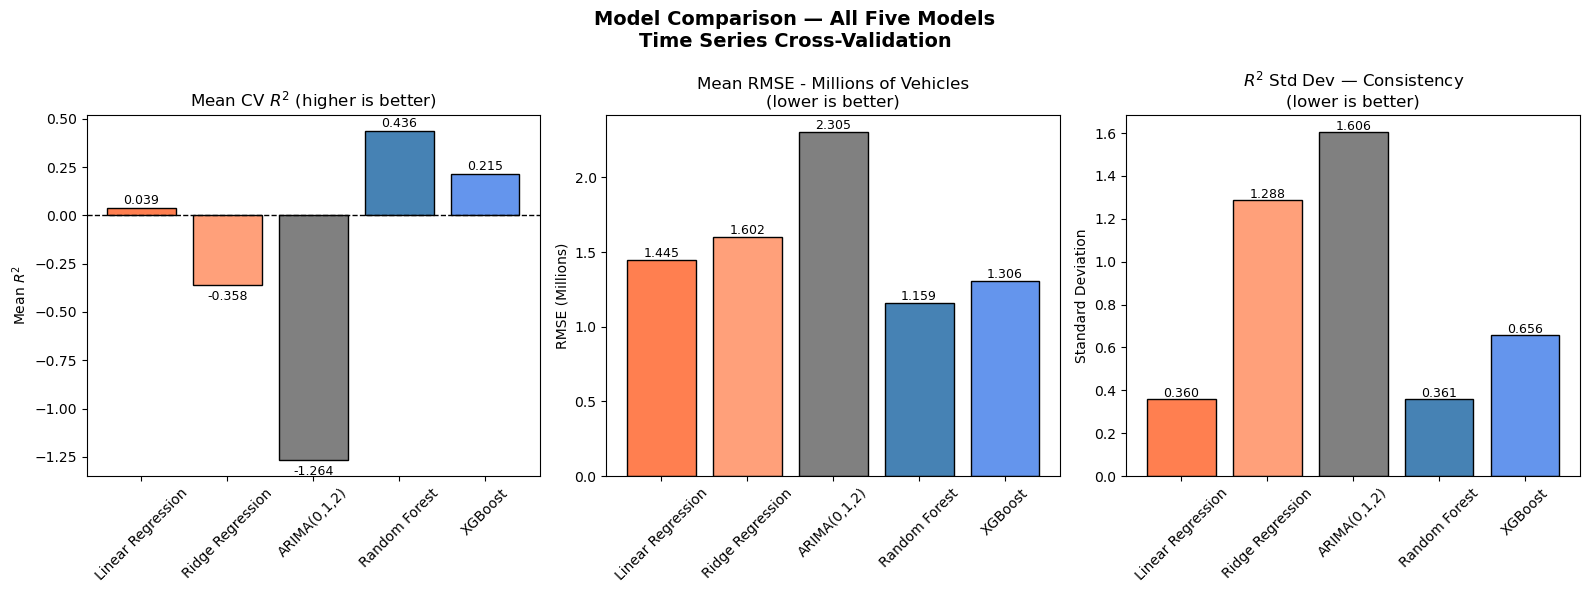


=== Final Model Comparison Table ===
            Model  Mean CV R²  Mean RMSE  R² Std
Linear Regression       0.039      1.445   0.360
 Ridge Regression      -0.358      1.602   1.288
     ARIMA(0,1,2)      -1.264      2.305   1.606
    Random Forest       0.436      1.159   0.361
          XGBoost       0.215      1.306   0.656


In [16]:
#  Overall Model Comparison 
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 
              'ARIMA(0,1,2)', 'Random Forest', 'XGBoost'],
    'Mean CV R²': [0.039, -0.358, -1.264, 0.436, 0.215],
    'Mean RMSE': [1.445, 1.602, 2.305, 1.159, 1.306],
    'R² Std': [0.360, 1.288, 1.606, 0.361, 0.656],
    'Primary Question': [
        'Economic drivers',
        'Economic drivers\n(clean coefficients)',
        'Temporal patterns',
        'Both questions',
        'Both questions'
    ]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Model Comparison — All Five Models\nTime Series Cross-Validation',
             fontsize=14, fontweight='bold')

colors = ['coral', 'lightsalmon', 'grey', 'steelblue', 'cornflowerblue']

# Panel 1: Mean CV R²
bars1 = axes[0].bar(comparison_df['Model'], comparison_df['Mean CV R²'],
                    color=colors, edgecolor='black')
axes[0].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Mean CV $R^2$ (higher is better)')
axes[0].set_ylabel('Mean $R^2$')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, comparison_df['Mean CV R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.08,
                 f'{val:.3f}', ha='center', fontsize=9)

# Panel 2: Mean RMSE
bars2 = axes[1].bar(comparison_df['Model'], comparison_df['Mean RMSE'],
                    color=colors, edgecolor='black')
axes[1].set_title('Mean RMSE - Millions of Vehicles\n(lower is better)')
axes[1].set_ylabel('RMSE (Millions)')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, comparison_df['Mean RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=9)

# Panel 3: R² Standard Deviation
bars3 = axes[2].bar(comparison_df['Model'], comparison_df['R² Std'],
                    color=colors, edgecolor='black')
axes[2].set_title('$R^2$ Std Dev — Consistency\n(lower is better)')
axes[2].set_ylabel('Standard Deviation')
axes[2].tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, comparison_df['R² Std']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Final Model Comparison Table ===")
print(comparison_df[['Model', 'Mean CV R²', 'Mean RMSE', 'R² Std']].to_string(index=False))

### 7.2 Overall Conclusions

**Model Performance Summary:**

| Model | Mean CV $R^2$ | Mean RMSE | $R^2$ Std | Primary Strength |
|-------|--------------|-----------|-----------|-----------------|
| Linear Regression | 0.039 | 1.445M | 0.360 | Interpretable economic relationships |
| Ridge Regression | -0.358 | 1.602M | 1.288 | Clean coefficient estimates |
| ARIMA(0,1,2) | -1.264 | 2.305M | 1.606 | Temporal structure (short-range only) |
| XGBoost | 0.215 | 1.306M | 0.656 | Non-linear relationships |
| **Random Forest** | **0.436** | **1.159M** | **0.361** | **Best overall** |

**Finding 1 - Random Forest is the best predictive model:**
Random Forest achieves the highest mean $R^2$ (0.436), lowest RMSE 
(1.159M) and second-best consistency (0.361) — winning on all three 
dimensions simultaneously. Crucially, it achieves this while being 
equally consistent as Linear Regression, meaning its superior 
performance is not at the cost of reliability.

**Finding 2 - Temporal features dominate short-range prediction:**
Both Random Forest and XGBoost assign ~95% of predictive importance 
to temporal features (lagged sales and rolling averages) and only ~5% 
to economic indicators. This reveals a fundamental insight:

> For **short-range month-to-month forecasting**, recent sales momentum 
> is far more informative than current economic conditions. Auto sales 
> are highly persistent - last month's sales ($sales\_lag\_1$) alone 
> accounts for 62% of Random Forest's predictive power.

**Finding 3 - Economic indicators explain why, not what next:**
Linear and Ridge regression — which use only economic indicators - 
cannot predict well across time periods (mean $R^2$ = 0.039 and -0.358 
respectively) but provide the most interpretable economic story:

- Unemployment is the dominant economic driver ($r = -0.689$, 
  coefficient = -0.574 after Ridge regularization)
- The recession effect is largely captured by unemployment - Ridge 
  reduces the recession coefficient from -0.823 to -0.245 by 
  separating overlapping influences
- Gas prices have almost no impact on sales volume ($r = -0.057$)

**Finding 4 - A new analytical question emerged:**
Random Forest's feature importance revealed a question not asked in 
Part 1: *do economic conditions drive sales directly, or do they 
operate through consumer behavior changes that first show up as 
momentum shifts in the sales series itself?* The dominance of 
`sales_lag_1` and `sales_rolling_3` suggests the latter — economic 
shocks may manifest as changes in sales momentum before they appear 
in the economic indicators themselves.

**Finding 5 - ARIMA is unsuitable for long-range forecasting:**
ARIMA(0,1,2) performs worst of all five models (mean $R^2$ = -1.264). 
As a univariate model it has no access to economic conditions and 
reverts to predicting the long-term mean when forecasting 8+ years 
ahead. ARIMA's value is in short-range forecasting (1-3 months) where 
its temporal structure is an advantage - not in the long-range 
cross-validation framework used here.

**Finding 6 - Ridge regression's value is interpretive, not predictive:**
Despite worse cross-validation performance than standard linear 
regression, Ridge provides the most reliable coefficient estimates 
by separating multicollinear predictors. The cleaned coefficients 
tell a more accurate economic story - the independent effect of each 
indicator after controlling for all others.

---

### 7.3 Limitations & Future Work

**Limitations:**
- All models struggle with **structural breaks** - the 2008 financial 
  crisis and COVID-19 pandemic remain difficult to predict regardless 
  of model sophistication
- **XGBoost hyperparameters** were not exhaustively tuned - a more 
  thorough grid search could potentially close the gap with Random Forest
- **ARIMA** was evaluated in a long-range forecasting framework that 
  does not reflect its intended use case. Short-range evaluation 
  (1-3 month horizon) would likely show much better performance
- **No ensemble model** was tested - combining Random Forest and 
  XGBoost predictions could potentially outperform either individually

**Future Work:**
- **Part 3** will apply the best performing model (Random Forest) 
  to regional U.S. data - testing whether the momentum-driven 
  prediction pattern holds across different geographic markets or 
  whether economic indicators play a larger role in specific regions
- **Ensemble modeling** - combining Random Forest and XGBoost 
  predictions as a weighted average or stacking approach
- **Shorter forecast horizons** - evaluating all models on 1, 3 
  and 6-month ahead forecasts rather than the 8-year horizon used 
  in cross-validation
- **SARIMA** - adding seasonal components to ARIMA may improve 
  performance, though Part 1 showed minimal seasonality in the data
- **Feature importance stability** - testing whether Random Forest's 
  feature importance rankings are consistent across different time 
  periods or whether they shift during economic regime changes

### 8. Dashboard

In [17]:
# Prepare prediction data for Tab 3 

# Random Forest predictions on full dataset
rf_full = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X, y_rf)
rf_predictions = rf_full.predict(X)

# XGBoost predictions on full dataset
xgb_full = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
xgb_full.fit(X, y_rf)
xgb_predictions = xgb_full.predict(X)

# Create predictions dataframe
df_predictions = pd.DataFrame({
    'date': X.index,
    'actual': y_rf.values,
    'random_forest': rf_predictions,
    'xgboost': xgb_predictions
})

print(f"Predictions prepared: {len(df_predictions)} rows")
print(df_predictions.head())

Predictions prepared: 576 rows
        date  actual  random_forest    xgboost
0 1977-01-01  14.396      14.394312  14.465416
1 1977-02-01  14.709      14.554843  14.606595
2 1977-03-01  15.170      14.838534  14.898768
3 1977-04-01  15.135      14.906120  14.959581
4 1977-05-01  14.984      14.910672  14.907308


In [18]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [19]:
# TAB 1 FIGURES - Model Performance 

# Figure 1: Model Comparison Bar Chart
fig_comparison = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Mean CV $R^2$', 
                    'Mean RMSE (Millions)',
                    '$R^2$ Std Dev — Consistency')
)

models = comparison_df['Model']
colors = ['coral', 'lightsalmon', 'grey', 'steelblue', 'cornflowerblue']

fig_comparison.add_trace(
    go.Bar(x=models, y=comparison_df['Mean CV R²'],
           marker_color=colors, text=comparison_df['Mean CV R²'].round(3),
           textposition='outside', name='R²', showlegend=False),
    row=1, col=1
)
fig_comparison.add_hline(y=0, line_color='black', line_width=1, row=1, col=1)

fig_comparison.add_trace(
    go.Bar(x=models, y=comparison_df['Mean RMSE'],
           marker_color=colors, text=comparison_df['Mean RMSE'].round(3),
           textposition='outside', name='RMSE', showlegend=False),
    row=1, col=2
)

fig_comparison.add_trace(
    go.Bar(x=models, y=comparison_df['R² Std'],
           marker_color=colors, text=comparison_df['R² Std'].round(3),
           textposition='outside', name='Std', showlegend=False),
    row=1, col=3
)

fig_comparison.update_layout(
    title='Model Comparison — All Five Models (Time Series Cross-Validation)',
    template='plotly_white',
    height=500
)
fig_comparison.update_xaxes(tickangle=45)

# Figure 2: CV Results by Fold for each model
fold_labels = ['1984-1992', '1992-2000', '2000-2008', '2008-2016', '2016-2024']

# R² by fold for tree-based models
rf_folds = [0.3594, -0.2024, 0.5881, 0.8858, 0.5489]
xgb_folds = [0.2546, -1.0289, 0.4128, 0.8810, 0.5579]
lr_folds = [0.1055, 0.3697, -1.1597, 0.7328, 0.1466]
arima_folds = [-0.1401, -4.3890, -0.8219, -0.0087, -0.9594]
ridge_folds = [-0.7143, 0.6416, -2.7290, 0.6693, 0.3432]

fig_folds = go.Figure()

for name, folds, color in [
    ('Linear Regression', lr_folds, 'coral'),
    ('Ridge Regression', ridge_folds, 'lightsalmon'),
    ('ARIMA(0,1,2)', arima_folds, 'grey'),
    ('Random Forest', rf_folds, 'steelblue'),
    ('XGBoost', xgb_folds, 'cornflowerblue')
]:
    fig_folds.add_trace(go.Scatter(
        x=fold_labels, y=folds,
        mode='lines+markers',
        name=name,
        line=dict(color=color, width=2),
        marker=dict(size=8)
    ))

fig_folds.add_hline(y=0, line_color='black', line_width=1, line_dash='dash')
fig_folds.update_layout(
    title='$R^2$ by Fold — All Models',
    xaxis_title='Test Period',
    yaxis_title='$R^2$ Score',
    template='plotly_white',
    height=450,
    legend=dict(x=0.01, y=0.99)
)

print("Tab 1 figures ready!")

Tab 1 figures ready!


In [20]:
# TAB 2 FIGURES - Feature Importance 

# Prepare feature importance data
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False)

# Figure 3: Random Forest Feature Importance
colors_rf = ['steelblue' if 'lag' in f or 'rolling' in f
             else 'coral' for f in rf_importance['Feature']]

fig_rf_imp = go.Figure(go.Bar(
    x=rf_importance['Importance'],
    y=rf_importance['Feature'],
    orientation='h',
    marker_color=colors_rf,
    text=rf_importance['Importance'].round(3),
    textposition='outside'
))

fig_rf_imp.update_layout(
    title='Random Forest — Feature Importance',
    xaxis_title='Importance Score',
    yaxis=dict(autorange='reversed'),
    template='plotly_white',
    height=450
)

# Figure 4: XGBoost Feature Importance
colors_xgb = ['steelblue' if 'lag' in f or 'rolling' in f
              else 'coral' for f in xgb_importance_df['Feature']]

fig_xgb_imp = go.Figure(go.Bar(
    x=xgb_importance_df['Importance'],
    y=xgb_importance_df['Feature'],
    orientation='h',
    marker_color=colors_xgb,
    text=xgb_importance_df['Importance'].round(3),
    textposition='outside'
))

fig_xgb_imp.update_layout(
    title='XGBoost — Feature Importance',
    xaxis_title='Importance Score',
    yaxis=dict(autorange='reversed'),
    template='plotly_white',
    height=450
)

# Figure 5: Side by side comparison of top features
# Merge both importance dataframes
importance_merged = rf_importance.merge(
    xgb_importance_df,
    on='Feature',
    suffixes=('_rf', '_xgb')
).sort_values('Importance_rf', ascending=False)

fig_imp_compare = go.Figure()

fig_imp_compare.add_trace(go.Bar(
    x=importance_merged['Feature'],
    y=importance_merged['Importance_rf'],
    name='Random Forest',
    marker_color='steelblue'
))

fig_imp_compare.add_trace(go.Bar(
    x=importance_merged['Feature'],
    y=importance_merged['Importance_xgb'],
    name='XGBoost',
    marker_color='coral'
))

fig_imp_compare.update_layout(
    barmode='group',
    title='Feature Importance Comparison — Random Forest vs XGBoost',
    xaxis_title='Feature',
    yaxis_title='Importance Score',
    xaxis=dict(tickangle=45),
    template='plotly_white',
    height=450,
    legend=dict(x=0.7, y=0.99)
)

print("Tab 2 figures ready!")

Tab 2 figures ready!


In [21]:
# TAB 3 FIGURES - Predictions 

# Figure 6: Actual vs Predicted — Random Forest
fig_rf_pred = go.Figure()

fig_rf_pred.add_trace(go.Scatter(
    x=df_predictions['date'],
    y=df_predictions['actual'],
    mode='lines',
    name='Actual Sales',
    line=dict(color='steelblue', width=1),
    opacity=0.7
))

fig_rf_pred.add_trace(go.Scatter(
    x=df_predictions['date'],
    y=df_predictions['random_forest'],
    mode='lines',
    name='Random Forest Predictions',
    line=dict(color='red', width=2, dash='dash')
))

# Recession shading
for _, row in recession_data.iterrows():
    fig_rf_pred.add_vrect(
        x0=row['start_date'], x1=row['end_date'],
        fillcolor='grey', opacity=0.15,
        layer='below', line_width=0
    )

fig_rf_pred.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='grey', width=10),
    opacity=0.15, name='Recession Period'
))

fig_rf_pred.update_layout(
    title='Random Forest — Actual vs Predicted Auto Sales (1977–2024)',
    xaxis_title='Date',
    yaxis_title='Auto Sales (Millions, SAAR)',
    template='plotly_white',
    height=450,
    legend=dict(x=0.01, y=0.99)
)

# Figure 7: Actual vs Predicted - XGBoost
fig_xgb_pred = go.Figure()

fig_xgb_pred.add_trace(go.Scatter(
    x=df_predictions['date'],
    y=df_predictions['actual'],
    mode='lines',
    name='Actual Sales',
    line=dict(color='steelblue', width=1),
    opacity=0.7
))

fig_xgb_pred.add_trace(go.Scatter(
    x=df_predictions['date'],
    y=df_predictions['xgboost'],
    mode='lines',
    name='XGBoost Predictions',
    line=dict(color='darkorange', width=2, dash='dash')
))

for _, row in recession_data.iterrows():
    fig_xgb_pred.add_vrect(
        x0=row['start_date'], x1=row['end_date'],
        fillcolor='grey', opacity=0.15,
        layer='below', line_width=0
    )

fig_xgb_pred.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='grey', width=10),
    opacity=0.15, name='Recession Period'
))

fig_xgb_pred.update_layout(
    title='XGBoost — Actual vs Predicted Auto Sales (1977–2024)',
    xaxis_title='Date',
    yaxis_title='Auto Sales (Millions, SAAR)',
    template='plotly_white',
    height=450,
    legend=dict(x=0.01, y=0.99)
)

# Figure 8: Residuals comparison
fig_residuals = go.Figure()

fig_residuals.add_trace(go.Scatter(
    x=df_predictions['date'],
    y=df_predictions['actual'] - df_predictions['random_forest'],
    mode='lines',
    name='Random Forest Residuals',
    line=dict(color='steelblue', width=1),
    opacity=0.7
))

fig_residuals.add_trace(go.Scatter(
    x=df_predictions['date'],
    y=df_predictions['actual'] - df_predictions['xgboost'],
    mode='lines',
    name='XGBoost Residuals',
    line=dict(color='darkorange', width=1),
    opacity=0.7
))

fig_residuals.add_hline(y=0, line_color='black', line_width=1)

for _, row in recession_data.iterrows():
    fig_residuals.add_vrect(
        x0=row['start_date'], x1=row['end_date'],
        fillcolor='grey', opacity=0.15,
        layer='below', line_width=0
    )

fig_residuals.update_layout(
    title='Residuals — Random Forest vs XGBoost',
    xaxis_title='Date',
    yaxis_title='Residual (Actual - Predicted)',
    template='plotly_white',
    height=450,
    legend=dict(x=0.01, y=0.99)
)

print("Tab 3 figures ready!")

Tab 3 figures ready!


In [22]:
#  BUILD DASH APP 
app = Dash(__name__)

TAB_STYLE = {
    'fontFamily': 'Arial, sans-serif',
    'fontSize': '15px',
    'padding': '10px'
}
SELECTED_TAB_STYLE = {
    **TAB_STYLE,
    'fontWeight': 'bold',
    'borderTop': '3px solid #1a5276',
    'color': '#1a5276'
}
SECTION_STYLE = {'padding': '0 20px 30px 20px'}
GRAPH_ROW_STYLE = {'display': 'flex', 'gap': '10px', 'marginBottom': '20px'}

app.layout = html.Div([

    html.H1(
        'U.S. Automobile Sales — Advanced Modeling Dashboard (Part 2)',
        style={
            'textAlign': 'center',
            'color': '#1a5276',
            'fontFamily': 'Arial, sans-serif',
            'fontSize': '20px',
            'padding': '20px 20px 5px 20px'
        }
    ),
    html.H3(
        'ARIMA · Linear Regression · Ridge Regression · Random Forest · XGBoost',
        style={
            'textAlign': 'center',
            'color': '#5d6d7e',
            'fontFamily': 'Arial, sans-serif',
            'fontWeight': 'normal',
            'fontSize': '14px',
            'padding': '0 0 15px 0'
        }
    ),

    dcc.Tabs([

        #  TAB 1: Model Performance 
        dcc.Tab(
            label='Model Performance',
            style=TAB_STYLE,
            selected_style=SELECTED_TAB_STYLE,
            children=[
                html.Div([
                    html.H2('Model Comparison — Time Series Cross-Validation',
                            style={'textAlign': 'center',
                                   'color': '#1a5276',
                                   'fontFamily': 'Arial, sans-serif',
                                   'paddingTop': '20px'}),
                    dcc.Graph(figure=fig_comparison,
                              style={'marginBottom': '20px'}),
                    dcc.Graph(figure=fig_folds)
                ], style=SECTION_STYLE)
            ]
        ),

        #  TAB 2: Feature Importance 
        dcc.Tab(
            label='Feature Importance',
            style=TAB_STYLE,
            selected_style=SELECTED_TAB_STYLE,
            children=[
                html.Div([
                    html.H2('Feature Importance — Random Forest & XGBoost',
                            style={'textAlign': 'center',
                                   'color': '#1a5276',
                                   'fontFamily': 'Arial, sans-serif',
                                   'paddingTop': '20px'}),
                    # Side by side individual importance charts
                    html.Div([
                        html.Div(dcc.Graph(figure=fig_rf_imp),
                                 style={'width': '50%'}),
                        html.Div(dcc.Graph(figure=fig_xgb_imp),
                                 style={'width': '50%'})
                    ], style=GRAPH_ROW_STYLE),
                    # Full width comparison
                    dcc.Graph(figure=fig_imp_compare)
                ], style=SECTION_STYLE)
            ]
        ),

        #  TAB 3: Predictions 
        dcc.Tab(
            label='Predictions',
            style=TAB_STYLE,
            selected_style=SELECTED_TAB_STYLE,
            children=[
                html.Div([
                    html.H2('Actual vs Predicted — Random Forest & XGBoost',
                            style={'textAlign': 'center',
                                   'color': '#1a5276',
                                   'fontFamily': 'Arial, sans-serif',
                                   'paddingTop': '20px'}),

                    # Year range slider
                    html.Div([
                        html.Label('Filter by Year Range:',
                                   style={'fontFamily': 'Arial, sans-serif',
                                          'fontWeight': 'bold',
                                          'marginBottom': '5px'}),
                        dcc.RangeSlider(
                            id='year-slider-p2',
                            min=1977,
                            max=2024,
                            step=1,
                            value=[1977, 2024],
                            marks={y: str(y) for y in range(1977, 2025, 4)},
                            tooltip={'placement': 'bottom',
                                     'always_visible': True}
                        )
                    ], style={'padding': '10px 40px 20px 40px'}),

                    # Model selector
                    html.Div([
                        html.Label('Select Model:',
                                   style={'fontFamily': 'Arial, sans-serif',
                                          'fontWeight': 'bold',
                                          'marginBottom': '5px'}),
                        dcc.Dropdown(
                            id='model-selector',
                            options=[
                                {'label': 'Random Forest', 
                                 'value': 'random_forest'},
                                {'label': 'XGBoost', 
                                 'value': 'xgboost'},
                                {'label': 'Both', 
                                 'value': 'both'}
                            ],
                            value='both',
                            clearable=False,
                            style={'width': '300px'}
                        )
                    ], style={'padding': '0 40px 10px 40px'}),

                    # Interactive prediction chart
                    dcc.Graph(id='pred-chart'),

                    # Residuals full width
                    dcc.Graph(figure=fig_residuals)

                ], style=SECTION_STYLE)
            ]
        )

    ])

], style={'backgroundColor': '#f9f9f9', 'minHeight': '100vh'})


#  CALLBACK — Update prediction chart 
@app.callback(
    Output('pred-chart', 'figure'),
    [Input('year-slider-p2', 'value'),
     Input('model-selector', 'value')]
)
def update_pred_chart(year_range, selected_model):
    start = pd.Timestamp(f'{year_range[0]}-01-01')
    end = pd.Timestamp(f'{year_range[1]}-12-31')

    filtered = df_predictions[
        (df_predictions['date'] >= start) &
        (df_predictions['date'] <= end)
    ]

    fig = go.Figure()

    # Actual sales always shown
    fig.add_trace(go.Scatter(
        x=filtered['date'],
        y=filtered['actual'],
        mode='lines',
        name='Actual Sales',
        line=dict(color='steelblue', width=1),
        opacity=0.7
    ))

    # Add selected model predictions
    if selected_model in ['random_forest', 'both']:
        fig.add_trace(go.Scatter(
            x=filtered['date'],
            y=filtered['random_forest'],
            mode='lines',
            name='Random Forest',
            line=dict(color='red', width=2, dash='dash')
        ))

    if selected_model in ['xgboost', 'both']:
        fig.add_trace(go.Scatter(
            x=filtered['date'],
            y=filtered['xgboost'],
            mode='lines',
            name='XGBoost',
            line=dict(color='darkorange', width=2, dash='dot')
        ))

    # Recession shading within selected range
    for _, row in recession_data.iterrows():
        rec_start = max(row['start_date'], start)
        rec_end = min(row['end_date'], end)
        if rec_start < rec_end:
            fig.add_vrect(
                x0=rec_start, x1=rec_end,
                fillcolor='grey', opacity=0.15,
                layer='below', line_width=0
            )

    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='lines',
        line=dict(color='grey', width=10),
        opacity=0.15, name='Recession Period'
    ))

    fig.update_layout(
        title=f'Auto Sales Predictions ({year_range[0]}–{year_range[1]})',
        xaxis_title='Date',
        yaxis_title='Auto Sales (Millions, SAAR)',
        template='plotly_white',
        height=500,
        legend=dict(x=0.01, y=0.99)
    )

    return fig


if __name__ == '__main__':
    app.run(debug=True, port=8051)